In [1]:
import os
import sys
from pathlib import Path

library_path = os.path.abspath('../../src')
if library_path not in sys.path:
    sys.path.append(library_path)
library_path = Path(library_path)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

DATA_PATH  = library_path.parent / 'data'
PLOTS_PATH = library_path.parent / 'plots'
PLOTS_PATH.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

In [3]:
from euroqol.utils import compute_weights, fit_lr_density_ratio, wmean_se, subgroup_norms

## Norm Derivation — Restricted Pipeline

### What this notebook does

This notebook derives population reference norms for seven EQ-5D-5L outcomes by applying
importance-weighted estimation to DAPHNIE 2024, using HSE 2017–2018 as the target population.

### Statistical rationale

The core idea is **importance weighting** (covariate shift correction). The density ratio
$w(x) = P_{\text{target}}(x) / P_{\text{source}}(x)$ transforms an expectation under the
source distribution into one under the target distribution:

$$\mathbb{E}_{\text{target}}[Y] \approx \frac{\sum_i w(x_i)\, y_i}{\sum_i w(x_i)}$$

where the sum is over DAPHNIE 2024 observations. When $w$ is well-estimated, this recovers
the population mean we would observe if DAPHNIE had been drawn from the same frame as HSE.

### Design

- **Density ratio:** re-estimated here from scratch using plain logistic regression on the
  15-variable predictor set — same architecture as notebook 031. Plain LR is the recommended
  scheme (best post-reweighting balance with 3 residual imbalanced variables, ESS ≈ 74.5%).
- **Reference:** HSE 2017–2018 survey-weighted with `wt_int`.
- **DAPHNIE unadjusted:** DAPHNIE 2024 design-weighted with `svy_wt`.
- **DAPHNIE adjusted:** weighted with `svy_wt × w_LR`.
- **Missingness:** complete-case analysis per outcome. ~10% block missing on EQ-5D in HSE
  2017–18 (not MCAR; systematically less healthy — stated limitation for abstract).

In [4]:
df = pd.read_csv(DATA_PATH / 'wrangled_data.csv', low_memory=False)

hse_2022   = df[df['dataset'] == 'HSE 2022'].copy().reset_index(drop=True)
daphnie_24 = df[df['dataset'] == 'DAPHNIE 2024'].copy().reset_index(drop=True)

print(f'HSE 2022: n = {len(hse_2022):,}')
print(f'DAPHNIE 2024:  n = {len(daphnie_24):,}')

HSE 2022: n = 7,590
DAPHNIE 2024:  n = 5,237


In [5]:
# 17-variable predictor set (notebook 031)
EXTRA_FEATURES = [
    "paVig", "paMod", "resp", "skin",
]
BASE_FEATURES = [
    "Sex", "age7cat", "eth2cat", "emp_cat_Employed", "emp_cat_Other (Sick/Home/etc)", "emp_cat_Retired",
    "emp_cat_Student", "emp_cat_Unemployed", "edu_cat_2", "smoke_ecig", "diabetes",
    "meds_num", "ill_dis"
]
ALL_FEATURES = BASE_FEATURES + EXTRA_FEATURES
ALL_FEATURES = [f for f in ALL_FEATURES if f in df.columns]
print(f"Features ({len(ALL_FEATURES)}):")
print(ALL_FEATURES)

Features (17):
['Sex', 'age7cat', 'eth2cat', 'emp_cat_Employed', 'emp_cat_Other (Sick/Home/etc)', 'emp_cat_Retired', 'emp_cat_Student', 'emp_cat_Unemployed', 'edu_cat_2', 'smoke_ecig', 'diabetes', 'meds_num', 'ill_dis', 'paVig', 'paMod', 'resp', 'skin']


## Step 1: Density Ratio Re-estimation

Plain logistic regression with `class_weight='balanced'` is trained to distinguish
DAPHNIE 2024 (label = 0) from HSE 2017–2018 (label = 1) using the 15 predictors.
Equalising the class prior means the predicted probability odds are directly the
density ratio:

$$w(x) = \frac{\hat{p}(x)}{1 - \hat{p}(x)}$$

No sample-size correction is needed because `class_weight='balanced'` already
absorbs the marginal class imbalance (DAPHNIE:HSE ≈ 1:3.1).

Weights are clipped at the 99th percentile to prevent extreme observations from
dominating the weighted estimator, then renormalised to mean 1.

In [6]:
lr_model = fit_lr_density_ratio(daphnie_24, hse_2022, ALL_FEATURES)
w_lr, clip_val, n_clipped, n_eff = compute_weights(lr_model, daphnie_24[ALL_FEATURES])

print('LR density ratio weights (99th-pct clip):')
print(f'  Clip value:          {clip_val:.3f}')
print(f'  Clipped observations: {n_clipped} ({100*n_clipped/len(daphnie_24):.1f}%)')
print(f'  ESS:                 {n_eff:.0f} / {len(daphnie_24)} ({100*n_eff/len(daphnie_24):.1f}%)')
print(f'  Weight range:        [{w_lr.min():.3f}, {w_lr.max():.3f}]  mean = {w_lr.mean():.3f}')

LR density ratio weights (99th-pct clip):
  Clip value:          6.404
  Clipped observations: 53 (1.0%)
  ESS:                 2483 / 5237 (47.4%)
  Weight range:        [0.012, 6.530]  mean = 1.000


## Step 2: Outcome Variables

Eight outcomes are in scope for the abstract analysis:

| Variable | Type | Description |
|---|---|---|
| `srh_2` | ordinal 1–5 | Self-rated health |
| `srh` | ordinal 1–5 | Self-rated health |

All analyses are complete-case per outcome.

In [7]:
OUTCOMES = ['srh', 'srh_2']

print(f'  {"Outcome":<14}  {"DAPHNIE 2024":>13}  {"HSE 2022":>12}')
print(f'  {"-"*42}')
for out in OUTCOMES:
    m_d = 100 * daphnie_24[out].isna().mean()
    m_h = 100 * hse_2022[out].isna().mean()
    print(f'  {out:<14}  {m_d:>12.1f}%  {m_h:>11.1f}%')

  Outcome          DAPHNIE 2024      HSE 2022
  ------------------------------------------
  srh                      6.1%          0.0%
  srh_2                    6.1%          0.0%


## Step 3: Population Norm Estimation

For each outcome, we estimate the population mean under three conditions:

| Condition | Sample | Weights |
|---|---|---|
| **HSE 2022** | HSE 2022 | `wt_int` (official survey weights) |
| **DAPHNIE (unadjusted)** | DAPHNIE 2024 | `svy_wt` (quota-sample design weights) |
| **DAPHNIE (adjusted)** | DAPHNIE 2024 | `svy_wt × w_LR` |

The estimator is the Horvitz–Thompson weighted mean. Standard errors use the sandwich
estimator, which is valid regardless of the weight distribution:

$$\widehat{\mathrm{SE}} = \sqrt{\frac{\sum_i w_i^2 (y_i - \bar{y}_w)^2}{\left(\sum_i w_i\right)^2}}$$

For binary outcomes (FULLHEALTH, % any problem per dimension), this reduces to the
weighted binomial proportion SE. Confidence intervals: $\bar{y}_w \pm 1.96\,\widehat{\mathrm{SE}}$.

In [8]:
# Positional weight arrays (aligned with each reset-indexed dataframe)
HSE_W   = hse_2022['wt_int'].fillna(1.0).values
D24_SWY = daphnie_24['svy_wt'].fillna(1.0).values
D24_ADJ = D24_SWY * w_lr

# (label, dataframe, weight_array) triples used throughout
CONDITIONS = [
    ('HSE 2022',          hse_2022,   HSE_W),
    ('DAPHNIE (unadjusted)', daphnie_24, D24_SWY),
    ('DAPHNIE (adjusted)',   daphnie_24, D24_ADJ),
]

COND_COLORS = {
    'HSE 2022':          '#2ca02c',
    'DAPHNIE (unadjusted)': '#d62728',
    'DAPHNIE (adjusted)':   '#1f77b4',
}

In [9]:
# Overall norms table: mean (95% CI) for each outcome under each condition
rows = []
for out in OUTCOMES:
    for cond_label, ds, wts in CONDITIONS:
        mu, se = wmean_se(ds[out].values, wts)
        n_obs  = int(np.isfinite(ds[out].values).sum())
        rows.append({
            'Outcome':   out,
            'Condition': cond_label,
            'n':         n_obs,
            'Mean':      mu,
            'SE':        se,
            'CI_lo':     mu - 1.96 * se,
            'CI_hi':     mu + 1.96 * se,
        })

norms_long = pd.DataFrame(rows)

# Wide format for display
norms_wide = (
    norms_long
    .pivot(index='Outcome', columns='Condition', values=['n', 'Mean', 'SE'])
    .reindex(OUTCOMES)
)
print('Population norms — weighted means and SEs:')
display(norms_wide.round(4))

Population norms — weighted means and SEs:


n                                 \
Condition DAPHNIE (adjusted) DAPHNIE (unadjusted)  HSE 2022   
Outcome                                                       
srh                4915.0000            4915.0000 7590.0000   
srh_2              4915.0000            4915.0000 7590.0000   

                        Mean                                               SE  \
Condition DAPHNIE (adjusted) DAPHNIE (unadjusted) HSE 2022 DAPHNIE (adjusted)   
Outcome                                                                         
srh                   3.0478               3.1808   3.9531             0.0220   
srh_2                 2.9618               3.0723   2.9719             0.0194   

                                         
Condition DAPHNIE (unadjusted) HSE 2022  
Outcome                                  
srh                     0.0156   0.0121  
srh_2                   0.0134   0.0116

## Step 4: Subgroup Norms by Sex × Age Group

EuroQoL population norms are conventionally reported stratified by sex and age group.
We use the `age7cat` variable (seven 10-year bands) and `Sex` (binary).

Weights for each subgroup are the same as overall — we restrict to the subgroup
and apply the pre-computed `svy_wt × w_LR` without renormalising within the
subgroup, preserving cross-subgroup comparability.

In [10]:
# Inspect coding before applying labels
print('age7cat distribution (DAPHNIE 2024):')
print(daphnie_24['age7cat'].value_counts().sort_index().to_string())
print()
print('age7cat distribution (HSE 2022):')
print(hse_2022['age7cat'].value_counts().sort_index().to_string())
print()
print('Sex distribution (DAPHNIE 2024):')
print(daphnie_24['Sex'].value_counts().sort_index().to_string())
print()
print('Sex distribution (HSE 2022):')
print(hse_2022['Sex'].value_counts().sort_index().to_string())

age7cat distribution (DAPHNIE 2024):
age7cat
1.0000    412
2.0000    915
3.0000    967
4.0000    968
5.0000    800
6.0000    811
7.0000    312

age7cat distribution (HSE 2022):
age7cat
1.0000     360
2.0000     887
3.0000    1148
4.0000    1175
5.0000    1380
6.0000    1452
7.0000    1188

Sex distribution (DAPHNIE 2024):
Sex
0.0000    2417
1.0000    2775

Sex distribution (HSE 2022):
Sex
0.0000    3425
1.0000    4165


In [11]:
# Adjust these mappings if the coding printout above differs from the labels here
AGE_LABELS = {1: '18–24', 2: '25–34', 3: '35–44', 4: '45–54',
              5: '55–64', 6: '65–74', 7: '75+'}
SEX_LABELS = {0: 'Male', 1: 'Female'}


def subgroup_norms(outcome, conditions, age_labels, sex_labels):
    """
    Compute weighted mean (and SE) for `outcome` within each Sex x age7cat cell.
    Returns a long-format DataFrame.
    """
    all_ages = sorted({int(v) for ds, _ in [(c[1], c[2]) for c in conditions]
                       for v in ds['age7cat'].dropna().unique()})
    all_sex  = sorted({int(v) for ds, _ in [(c[1], c[2]) for c in conditions]
                       for v in ds['Sex'].dropna().unique()})

    rows = []
    for sex_val in all_sex:
        for age_val in all_ages:
            for cond_label, ds, wts_arr in conditions:
                mask   = ((ds['Sex'] == sex_val) & (ds['age7cat'] == age_val)).values
                y_sub  = ds[outcome].values[mask]
                w_sub  = wts_arr[mask]
                mu, se = wmean_se(y_sub, w_sub)
                rows.append({
                    'Sex':       sex_labels.get(sex_val,  str(sex_val)),
                    'Age group': age_labels.get(age_val,  str(age_val)),
                    'Condition': cond_label,
                    'n':         int(mask.sum()),
                    'mean':      mu,
                    'SE':        se,
                })
    return pd.DataFrame(rows)


# EQ_index subgroup norms
sg_eq = subgroup_norms('srh_2', CONDITIONS, AGE_LABELS, SEX_LABELS)
sg_eq_wide = (
    sg_eq
    .pivot(index=['Sex', 'Age group'], columns='Condition', values=['n', 'mean', 'SE'])
)
print('EQ-5D-5L utility index — weighted norms by sex and age group:')
display(sg_eq_wide.round(4))

EQ-5D-5L utility index — weighted norms by sex and age group:


n                                \
Condition        DAPHNIE (adjusted) DAPHNIE (unadjusted) HSE 2022   
Sex    Age group                                                    
Female 18–24               207.0000             207.0000 181.0000   
       25–34               486.0000             486.0000 514.0000   
       35–44               574.0000             574.0000 632.0000   
       45–54               530.0000             530.0000 664.0000   
       55–64               431.0000             431.0000 757.0000   
       65–74               384.0000             384.0000 781.0000   
       75+                 136.0000             136.0000 636.0000   
Male   18–24               202.0000             202.0000 179.0000   
       25–34               424.0000             424.0000 373.0000   
       35–44               391.0000             391.0000 516.0000   
       45–54               432.0000             432.0000 511.0000   
       55–64               360.0000             360.0000 623.0000   
       65–74               413.0000             413.0000 671.0000   
       75+                 173.0000             173.0000 552.0000   

                               mean                                \
Condition        DAPHNIE (adjusted) DAPHNIE (unadjusted) HSE 2022   
Sex    Age group                                                    
Female 18–24                 3.1443               3.3433   3.2384   
       25–34                 3.1509               3.2039   3.1859   
       35–44                 2.8725               2.9914   3.0898   
       45–54                 2.6834               2.7450   2.9359   
       55–64                 2.8813               2.8886   2.8441   
       65–74                 2.9857               3.0282   2.7267   
       75+                   2.9191               2.9998   2.5619   
Male   18–24                 3.4265               3.4026   3.2880   
       25–34                 3.3387               3.4075   3.3046   
       35–44                 3.1740               3.2523   3.0902   
       45–54                 2.8927               2.9280   3.0417   
       55–64                 2.7725               2.8826   2.8401   
       65–74                 2.8628               2.9701   2.6942   
       75+                   2.9245               2.9430   2.5897   

                                 SE                                
Condition        DAPHNIE (adjusted) DAPHNIE (unadjusted) HSE 2022  
Sex    Age group                                                   
Female 18–24                 0.1105               0.0570   0.0688  
       25–34                 0.0583               0.0404   0.0364  
       35–44                 0.0661               0.0414   0.0389  
       45–54                 0.0712               0.0453   0.0397  
       55–64                 0.0647               0.0482   0.0370  
       65–74                 0.0629               0.0492   0.0352  
       75+                   0.0895               0.0672   0.0375  
Male   18–24                 0.0810               0.0576   0.0570  
       25–34                 0.0586               0.0404   0.0440  
       35–44                 0.0696               0.0464   0.0391  
       45–54                 0.0696               0.0475   0.0452  
       55–64                 0.0726               0.0524   0.0393  
       65–74                 0.0541               0.0431   0.0375  
       75+                   0.0928               0.0732   0.0415

In [12]:
# Subgroup norms for all abstract outcomes
sg_all = {}
for out in OUTCOMES:
    sg_all[out] = subgroup_norms(out, CONDITIONS, AGE_LABELS, SEX_LABELS)

# Combined table: mean only, one outcome per column-group, sex x age as index
means_by_cond = {}
for out in OUTCOMES:
    tmp = sg_all[out].pivot(index=['Sex', 'Age group'], columns='Condition', values='mean')
    tmp.columns = pd.MultiIndex.from_product([[out], tmp.columns])
    means_by_cond[out] = tmp

sg_combined = pd.concat(means_by_cond.values(), axis=1)
print('Subgroup norms — weighted means by Sex × Age group (all abstract outcomes):')
display(sg_combined.round(4))

Subgroup norms — weighted means by Sex × Age group (all abstract outcomes):


srh                                \
Condition        DAPHNIE (adjusted) DAPHNIE (unadjusted) HSE 2022   
Sex    Age group                                                    
Female 18–24                 3.3079               3.5283   4.2384   
       25–34                 3.2597               3.3458   4.1825   
       35–44                 2.9523               3.0728   4.0807   
       45–54                 2.7191               2.7961   3.9155   
       55–64                 2.9317               2.9606   3.8106   
       65–74                 3.0724               3.1050   3.6853   
       75+                   3.0146               3.0544   3.5294   
Male   18–24                 3.7149               3.6394   4.2880   
       25–34                 3.5388               3.6050   4.3046   
       35–44                 3.3361               3.4257   4.0826   
       45–54                 2.9439               2.9924   4.0238   
       55–64                 2.8181               2.9398   3.8117   
       65–74                 2.8886               3.0158   3.6641   
       75+                   2.9425               2.9734   3.5414   

                              srh_2                                
Condition        DAPHNIE (adjusted) DAPHNIE (unadjusted) HSE 2022  
Sex    Age group                                                   
Female 18–24                 3.1443               3.3433   3.2384  
       25–34                 3.1509               3.2039   3.1859  
       35–44                 2.8725               2.9914   3.0898  
       45–54                 2.6834               2.7450   2.9359  
       55–64                 2.8813               2.8886   2.8441  
       65–74                 2.9857               3.0282   2.7267  
       75+                   2.9191               2.9998   2.5619  
Male   18–24                 3.4265               3.4026   3.2880  
       25–34                 3.3387               3.4075   3.3046  
       35–44                 3.1740               3.2523   3.0902  
       45–54                 2.8927               2.9280   3.0417  
       55–64                 2.7725               2.8826   2.8401  
       65–74                 2.8628               2.9701   2.6942  
       75+                   2.9245               2.9430   2.5897

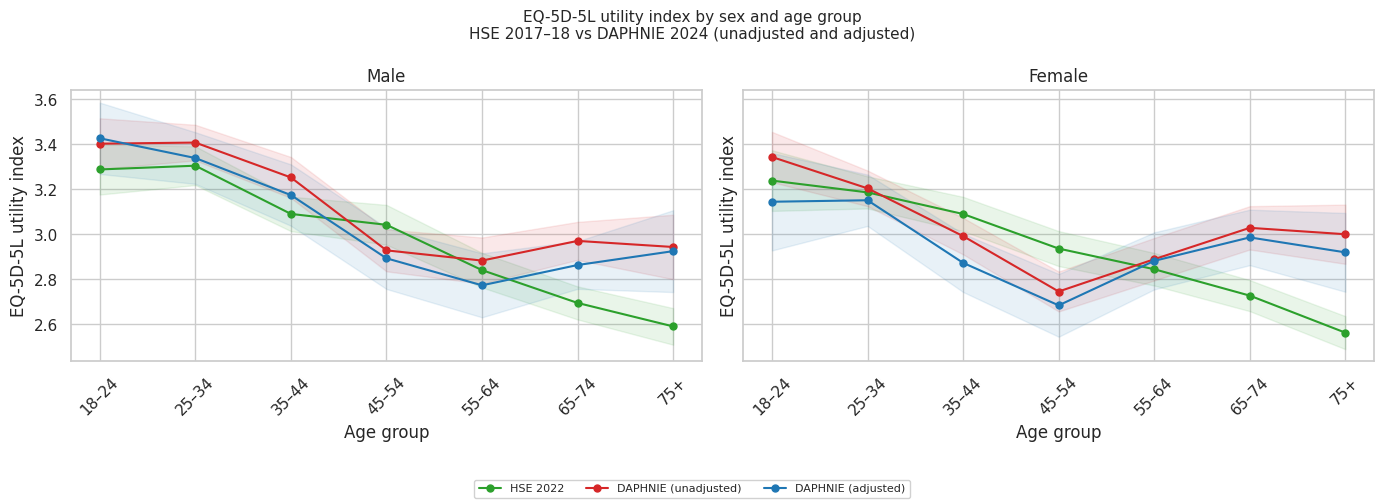

In [13]:
# EQ_index subgroup norm plot: adjusted DAPHNIE vs HSE reference
age_order = [AGE_LABELS[k] for k in sorted(AGE_LABELS)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, sex_lbl in zip(axes, ['Male', 'Female']):
    for cond_label, ds, wts_arr in CONDITIONS:
        sub = sg_eq[(sg_eq['Sex'] == sex_lbl) & (sg_eq['Condition'] == cond_label)]
        sub = sub.set_index('Age group').reindex(age_order)
        ax.plot(
            age_order, sub['mean'],
            marker='o', linewidth=1.5, markersize=5,
            label=cond_label, color=COND_COLORS[cond_label],
        )
        ax.fill_between(
            age_order,
            sub['mean'] - 1.96 * sub['SE'],
            sub['mean'] + 1.96 * sub['SE'],
            color=COND_COLORS[cond_label], alpha=0.10,
        )

    ax.set_title(sex_lbl)
    ax.set_xlabel('Age group')
    ax.set_ylabel('EQ-5D-5L utility index')
    ax.tick_params(axis='x', rotation=45)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=8, framealpha=0.9)
fig.suptitle('EQ-5D-5L utility index by sex and age group\n'
             'HSE 2017–18 vs DAPHNIE 2024 (unadjusted and adjusted)',
             fontsize=11)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig(PLOTS_PATH / 'eq_index_subgroup_norms_srh_2_DAPHNIE24_HSE22_all_features.png', dpi=150, bbox_inches='tight')
plt.show()

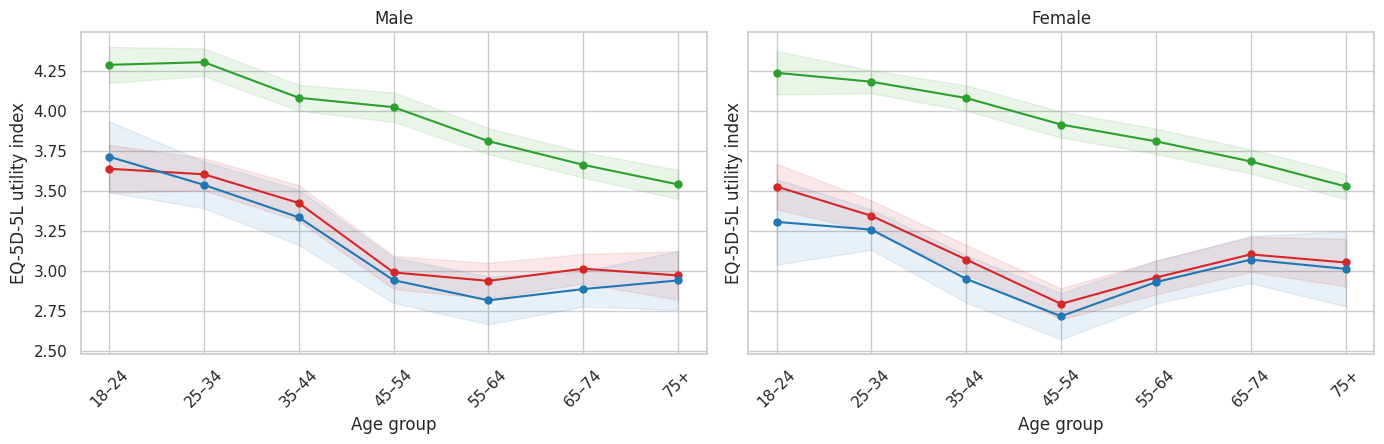

In [14]:
sg_eq = subgroup_norms('srh', CONDITIONS, AGE_LABELS, SEX_LABELS)
ig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, sex_lbl in zip(axes, ['Male', 'Female']):
    for cond_label, ds, wts_arr in CONDITIONS:
        sub = sg_eq[(sg_eq['Sex'] == sex_lbl) & (sg_eq['Condition'] == cond_label)]
        sub = sub.set_index('Age group').reindex(age_order)
        ax.plot(
            age_order, sub['mean'],
            marker='o', linewidth=1.5, markersize=5,
            label=cond_label, color=COND_COLORS[cond_label],
        )
        ax.fill_between(
            age_order,
            sub['mean'] - 1.96 * sub['SE'],
            sub['mean'] + 1.96 * sub['SE'],
            color=COND_COLORS[cond_label], alpha=0.10,
        )

    ax.set_title(sex_lbl)
    ax.set_xlabel('Age group')
    ax.set_ylabel('EQ-5D-5L utility index')
    ax.tick_params(axis='x', rotation=45)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=8, framealpha=0.9)
fig.suptitle('EQ-5D-5L utility index by sex and age group\n'
             'HSE 2017–18 vs DAPHNIE 2024 (unadjusted and adjusted)',
             fontsize=11)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig(PLOTS_PATH / 'eq_index_subgroup_norms_srh_DAPHNIE24_HSE22_all_features.png', dpi=600, bbox_inches='tight')
plt.show()